**Навигация по уроку**

1. [Первое знакомство с AutoML](https://colab.research.google.com/drive/1bCWyzlp1-tcvt7TE60m4hFnRd5AWscWY)
2. [Гиперпараметры и оптимизация моделей](https://colab.research.google.com/drive/1CN69NftfVXUliyv11FGbM7qOYbO0XON5)
3. [AutoML в Keras](https://colab.research.google.com/drive/1V7mfY8da0S-FbWxhQbchJM38JSJBmtoZ)
4. Домашняя работа

В домашней работе необходимо с помощью AutoKeras или KerasTuner найти оптимальную модель для решения одной из следующей задач:

1. На 3 балла. Обучите модель с точностью не менее 90% предсказывать сарказм в новостных заголовках. Составьте 5 произвольных заголовков, которых нет в датасете и проверьте на них обученную модель, сделайте выводы. Ссылка на [датасет](https://storage.yandexcloud.net/academy.ai/Sarcasm_Headlines_Dataset_v2.json.zip).
2. На 4 балла. Используйте [русский корпус новостей от Lenta.ru](https://www.kaggle.com/datasets/yutkin/corpus-of-russian-news-articles-from-lenta/data) подберите и обучите модель классифицировать новости по заголовкам на классы (поле topic в датасете). Используйте 9 самых часто встречаемых топиков и 10-й для остальных, не вошедших в 9 классов. Оцените модель с помощью отчета о классификации, сделайте выводы.  
3. На 5 баллов. Найдите публичный датасет по обращениям граждан в администрацию, техническую поддержку или за консультацией. Обучите модель классифицировать обращения по тематикам. Сформируйте отчет о классификации и матрицу ошибок.

In [ ]:
!pip install jax==0.5.2 ml-dtypes==0.4.0 grpcio-status==1.71.0 protobuf==5.26.1 tf-keras==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully un

In [ ]:
import tensorflow as tf
tf.__version__

'2.18.1'

In [ ]:
import keras_nlp as nlp
nlp.__version__

'0.19.3'

In [ ]:
!pip install --upgrade autokeras

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import autokeras as ak
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:


data = pd.read_csv('/content/customer_support_tickets.csv')

data_sample = data.sample(n=1000, random_state=42)

data_sample = data_sample.dropna()

In [ ]:
# Разделение данных на обучающую, тестовую и контрольную выборки
train_data, temp_data = train_test_split(data_sample, test_size=0.3, random_state=42)  # 70% для обучения, 30% для теста и контроля
test_data, control_data = train_test_split(temp_data, test_size=0.5, random_state=42)  # 15% для теста, 15% для контроля

In [ ]:
# Кодирование категориальных переменных
label_encoders = {}
categorical_columns = ['Customer Gender', 'Product Purchased', 'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Ticket Priority', 'Ticket Channel']

for column in categorical_columns:
    le = LabelEncoder()
    train_data[column] = le.fit_transform(train_data[column])
    test_data[column] = le.transform(test_data[column])
    control_data[column] = le.transform(control_data[column])
    label_encoders[column] = le  # Сохраняю кодировщики

# Преобразование столбцов с датами в числовые форматы
if 'Date of Purchase' in train_data.columns:
    train_data['Date of Purchase'] = pd.to_datetime(train_data['Date of Purchase'])
    test_data['Date of Purchase'] = pd.to_datetime(test_data['Date of Purchase'])
    control_data['Date of Purchase'] = pd.to_datetime(control_data['Date of Purchase'])

    # Преобразуем в количество дней с начала
    min_date = train_data['Date of Purchase'].min()
    train_data['Days Since Purchase'] = (train_data['Date of Purchase'] - min_date).dt.days
    test_data['Days Since Purchase'] = (test_data['Date of Purchase'] - min_date).dt.days
    control_data['Days Since Purchase'] = (control_data['Date of Purchase'] - min_date).dt.days

# Нормализация числовых переменных..
scaler = StandardScaler()
numerical_columns = ['Customer Age', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'Days Since Purchase']

In [ ]:
# Проверка размеров выборок?
print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")
print(f"Control data size: {len(control_data)}")

# Проверка на наличие NaN значений после обработки
print("NaN values in training data:", train_data.isnull().sum().sum())
print("NaN values in testing data:", test_data.isnull().sum().sum())
print("NaN values in control data:", control_data.isnull().sum().sum())

In [ ]:

data = train_data[['Customer Age', 'Customer Gender', 'Product Purchased', 'Ticket Description', 'Ticket Subject']]
data['Ticket Subject'] = LabelEncoder().fit_transform(data['Ticket Subject'])

# Разделение данных
X = data[['Customer Age', 'Customer Gender', 'Product Purchased', 'Ticket Description']]
y = data['Ticket Subject'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Trial 2 Complete [00h 48m 37s]
val_loss: 3.0282504558563232

Best val_loss So Far: 3.0282504558563232
Total elapsed time: 01h 36m 59s


6/6 ━━━━━━━━━━━━━━━━━━━━ 3215s 528s/step - accuracy: 0.1008 - loss: 2.9637


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 1 variables whereas the saved optimizer has 403 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(32, 1))
  warnings.warn(msg)


2/2 ━━━━━━━━━━━━━━━━━━━━ 312s 104s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 296s 97s/step
              precision    recall  f1-score   support

           0       0.08      1.00      0.15         4
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         8
           7       0.00      0.00      0.00         5
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         3
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         4
          12       0.00      0.00      0.00         3
          13       0.00      0.00      0.00         1
          14       0.00      0.00      0.00         2
          15       0.00      0.00      0.00         2

 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


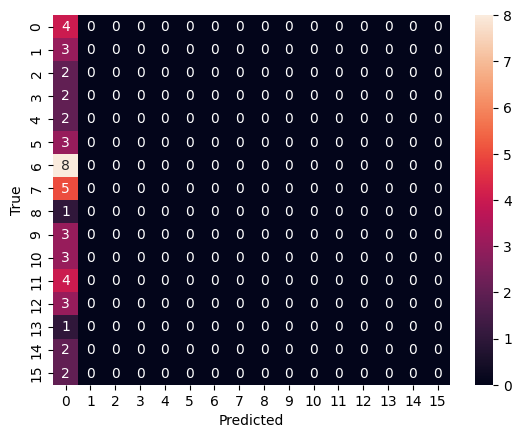

      Ticket ID      Customer Name                  Customer Email  \
3795       3796      Casey Higgins  randallchristopher@example.net   
7766       7767       Paige Bailey        rodriguezamy@example.net   
1731       1732       Terri Guzman           melissa00@example.org   
1417       1418  Kristopher Garcia         bradleypaul@example.net   
3289       3290    Kenneth Burnett        cooperashley@example.com   

      Customer Age  Customer Gender  Product Purchased Date of Purchase  \
3795            59                2                  3       2020-07-19   
7766            52                2                 18       2020-02-20   
1731            34                1                 36       2020-01-09   
1417            59                1                 27       2020-02-14   
3289            39                2                 34       2021-10-22   

      Ticket Type  Ticket Subject  \
3795            0              13   
7766            3              11   
1731            2

In [ ]:
# Обучение модели
text_input_train = X_train['Ticket Description'].values.reshape(-1, 1)
model = ak.TextClassifier(max_trials=2)
model.fit(text_input_train, y_train, epochs=1)

# Оценка модели
text_input_test = X_test['Ticket Description'].values.reshape(-1, 1)
y_pred = model.predict(text_input_test)
y_pred_classes = y_pred.argmax(axis=-1)

# Отчет о классификации и матрица ошибок
print(classification_report(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()